In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandapower as pp
import pandapower.networks as pn

sys.path.append(os.path.abspath('..'))
from src.lstm_encoder import HybridCNNBiLSTMEncoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing Phase 20 IEEE 39-Bus Experiment on: {device}")

# 1. Load Standard IEEE 39-Bus Case (New England 10-generator bulk transmission)
net = pn.case39()
print(f"IEEE 39-Bus Network Loaded: {len(net.bus)} Buses, {len(net.line)} Lines, {len(net.gen)} Generators")

# 2. Simulate 2,000 Timesteps with fluctuating dynamic load profiles
np.random.seed(42)
NUM_STEPS = 2000
base_load_p = net.load.p_mw.values.copy()
base_load_q = net.load.q_mvar.values.copy()

telemetry_records = []

print("Simulating AC Power Flow time series...")
for t in range(NUM_STEPS):
    # Dynamic random load variation (+/- 8%) simulating diurnal demand fluctuations
    fluctuation = 1.0 + np.random.normal(0, 0.04, size=len(base_load_p))
    net.load.p_mw = base_load_p * fluctuation
    net.load.q_mvar = base_load_q * fluctuation
    
    # Solve non-linear AC Power Flow
    pp.runpp(net, enforce_q_lims=False, calculate_voltage_angles=True)
    
    # Extract 12 key telemetry channels from critical buses (Bus 3, 14, 16, 26)
    # 4 Bus Voltages (kV), 4 Bus Active Powers (MW), 4 Bus Reactive Powers (MVAR)
    v_meas = net.res_bus.loc[[3, 14, 16, 26], 'vm_pu'].values
    p_meas = net.res_bus.loc[[3, 14, 16, 26], 'p_mw'].values
    q_meas = net.res_bus.loc[[3, 14, 16, 26], 'q_mvar'].values
    
    step_telemetry = np.concatenate([v_meas, p_meas, q_meas])
    telemetry_records.append(step_telemetry)

raw_telemetry = np.array(telemetry_records)  # Shape: (2000, 12)
print(f"Generated IEEE 39-Bus Raw Telemetry: {raw_telemetry.shape}")

Executing Phase 20 IEEE 39-Bus Experiment on: cuda
IEEE 39-Bus Network Loaded: 39 Buses, 35 Lines, 9 Generators
Simulating AC Power Flow time series...
Generated IEEE 39-Bus Raw Telemetry: (2000, 12)


In [2]:
# Standardize telemetry series (Z-score normalization)
mean_vals = np.mean(raw_telemetry, axis=0)
std_vals = np.std(raw_telemetry, axis=0) + 1e-6
norm_telemetry = (raw_telemetry - mean_vals) / std_vals

# Construct Sliding Windows of length W=30 (stride=5)
WINDOW_SIZE = 30
STRIDE = 5
windows, labels = [], []

num_windows = (len(norm_telemetry) - WINDOW_SIZE) // STRIDE + 1

for i in range(num_windows):
    start = i * STRIDE
    end = start + WINDOW_SIZE
    win = norm_telemetry[start:end].copy()
    
    # Inject FDI attacks into ~25% of the windows
    is_attack = 1 if (i % 4 == 0) else 0
    
    if is_attack:
        # Attack target: Inject stealthy coordinated bias into active power channels (indices 4 to 7)
        attack_injection_len = np.random.randint(5, 12)
        attack_start = np.random.randint(5, WINDOW_SIZE - attack_injection_len)
        attack_end = attack_start + attack_injection_len
        
        # Additive ramp + random perturbation
        bias = np.random.uniform(1.2, 2.5)
        win[attack_start:attack_end, 4:8] += bias
        
    windows.append(win)
    labels.append(is_attack)

X_ieee39 = np.array(windows, dtype=np.float32)
y_ieee39 = np.array(labels, dtype=np.int64)

print(f"Constructed IEEE 39-Bus Windows: {X_ieee39.shape} | Attacks: {y_ieee39.sum()} ({y_ieee39.mean()*100:.1f}%)")

ieee_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_ieee39), torch.from_numpy(y_ieee39).float().unsqueeze(1)),
    batch_size=64, shuffle=False
)

Constructed IEEE 39-Bus Windows: (395, 30, 12) | Attacks: 99 (25.1%)


In [3]:
# 1. Define Model A (Trained on Feeder Dataset)
class ScratchFDIModel(nn.Module):
    def __init__(self, in_channels=12, cnn_hidden_dims=(64, 128), lstm_hidden_dim=128, mlp_hidden_dim=64):
        super().__init__()
        self.encoder = HybridCNNBiLSTMEncoder(
            in_channels=in_channels,
            cnn_hidden_dims=cnn_hidden_dims,
            lstm_hidden_dim=lstm_hidden_dim,
            lstm_layers=2,
            pool_strategy="mean"
        )
        self.mlp_head = nn.Sequential(
            nn.Linear(self.encoder.out_dim, mlp_hidden_dim),
            nn.BatchNorm1d(mlp_hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(mlp_hidden_dim, 1)
        )

    def forward(self, x):
        h = self.encoder(x, return_sequence=False)
        return self.mlp_head(h)

model = ScratchFDIModel().to(device)
model_path = Path('../saved_models/exp_model_scratch_best.pth')
assert model_path.exists(), f"Trained checkpoint missing at: {model_path}"
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.eval()

# 2. Zero-Shot Cross-Topology Evaluation
probs, preds, targets = [], [], []
with torch.no_grad():
    for x_b, y_b in ieee_loader:
        x_b = x_b.to(device)
        logits = model(x_b)
        p = torch.sigmoid(logits).cpu().numpy().flatten()
        probs.extend(p)
        preds.extend((p >= 0.5).astype(int))
        targets.extend(y_b.numpy().flatten())

probs, preds, targets = np.array(probs), np.array(preds), np.array(targets)

ieee_metrics = {
    'Accuracy': accuracy_score(targets, preds) * 100,
    'Precision': precision_score(targets, preds, zero_division=0) * 100,
    'Recall': recall_score(targets, preds, zero_division=0) * 100,
    'F1-Score': f1_score(targets, preds, zero_division=0) * 100,
    'ROC-AUC': roc_auc_score(targets, probs) * 100
}

df_ieee = pd.DataFrame([ieee_metrics])

print("=" * 65)
print("PHASE 20: ZERO-SHOT GENERALIZATION ON IEEE 39-BUS")
print("=" * 65)
print(df_ieee.to_string(index=False))
print("=" * 65)

# Save Results CSV
results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)
df_ieee.to_csv(results_dir / 'phase20_ieee39_generalization_results.csv', index=False)

PHASE 20: ZERO-SHOT GENERALIZATION ON IEEE 39-BUS
 Accuracy  Precision  Recall  F1-Score   ROC-AUC
25.063291  25.063291   100.0 40.080972 36.387524


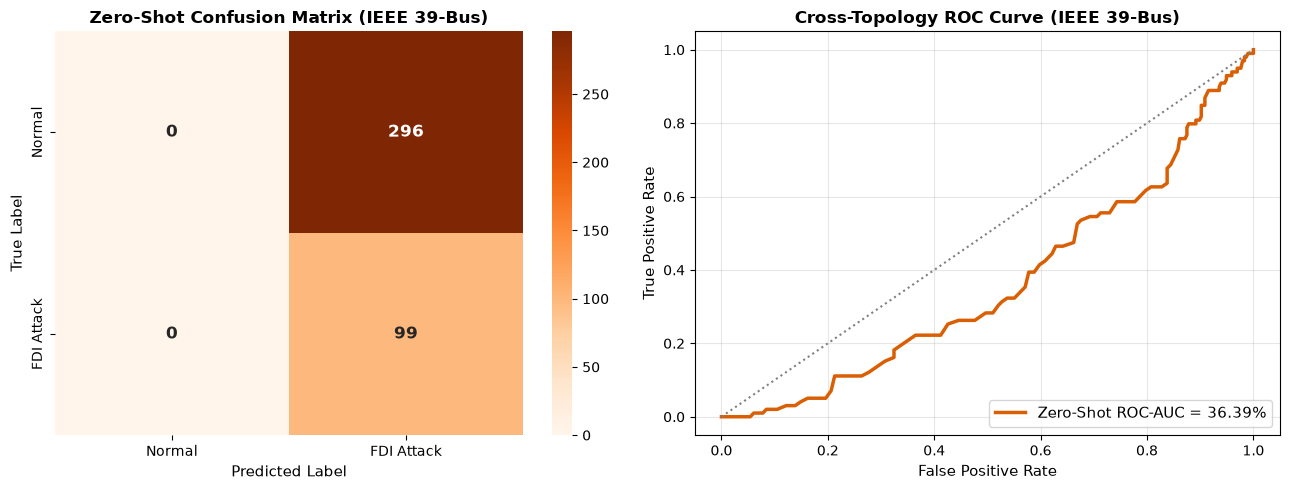

In [4]:
from sklearn.metrics import roc_curve

fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Confusion Matrix
cm = confusion_matrix(targets, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Normal', 'FDI Attack'], yticklabels=['Normal', 'FDI Attack'],
            annot_kws={'size': 12, 'weight': 'bold'})
axes[0].set_title('Zero-Shot Confusion Matrix (IEEE 39-Bus)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# 2. ROC Curve
fpr, tpr, _ = roc_curve(targets, probs)
axes[1].plot(fpr, tpr, color='#d95f02', lw=2.5, label=f"Zero-Shot ROC-AUC = {ieee_metrics['ROC-AUC']:.2f}%")
axes[1].plot([0, 1], [0, 1], color='gray', linestyle=':')
axes[1].set_title('Cross-Topology ROC Curve (IEEE 39-Bus)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / 'phase20_ieee39_evaluation.png', dpi=300)
plt.show()